# Titanic Survival Prediction - 
### A Logistic Regression Project

In [5]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
## Loading the Dataset
train = pd.read_csv("/Users/mac/Desktop/Desktop_Files/Projects/Titanic Survival Prediction/titanic_train.csv")

In [7]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


- Parch = parents and Children
- Sibsp = Siblings and Spouse

In [8]:
train.shape

(891, 12)

### Checking for Missing Values

In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

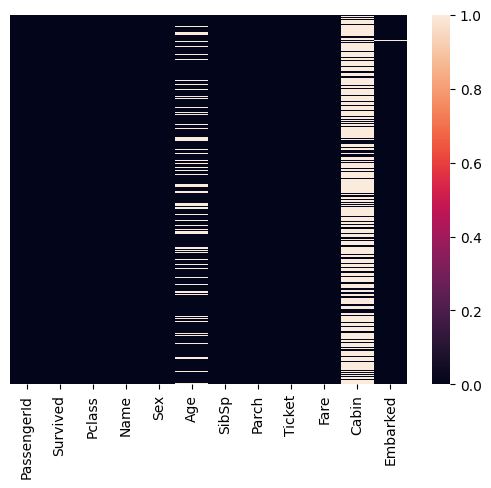

In [10]:
sns.heatmap(train.isnull(), yticklabels=False)

In [11]:
## Checking for Missing Values in percentage in each column
features_with_na = [features for features in train.columns if train[features].isnull().sum()>1]
features_with_na

['Age', 'Cabin', 'Embarked']

In [12]:
## Printing the %age of missing values in each column with missing values
for feature in features_with_na:
    print(feature, np.round(train[feature].isnull().mean()*100, 4), ' % missing values')

Age 19.8653  % missing values
Cabin 77.1044  % missing values
Embarked 0.2245  % missing values


- 20% of age data is missing
- 77% of Cabin data is missing

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_28805/3781976998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train, palette='mako')


<Axes: xlabel='Survived', ylabel='count'>

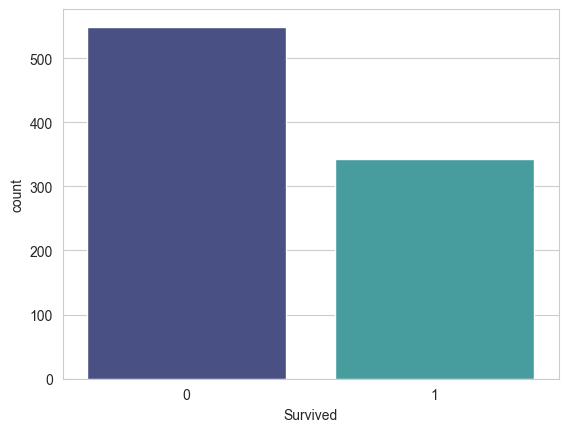

In [13]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train, palette='mako')

### Chekcing Survival relation with the Sex of the Passenger, 
- If they have any relation with their survival rate

<Axes: xlabel='Survived', ylabel='count'>

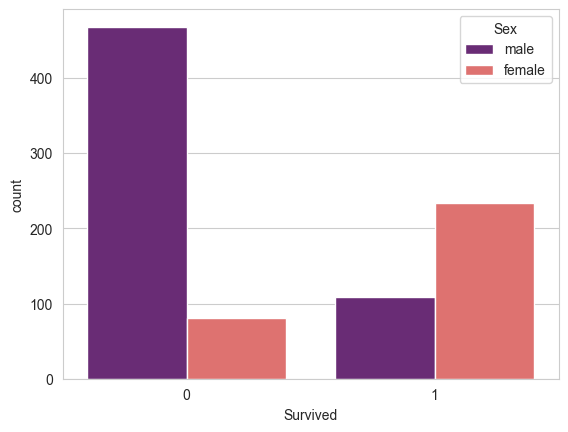

In [14]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='magma')

### Findingd-> Females had higher survival rate
- among survived ones, Females survived more.
- Same happened for "Those Who didn't Survive" , here Females were minority.

### Checkin with the Pclass , {Passenger Class}
- If there is any relation 

<Axes: xlabel='Survived', ylabel='count'>

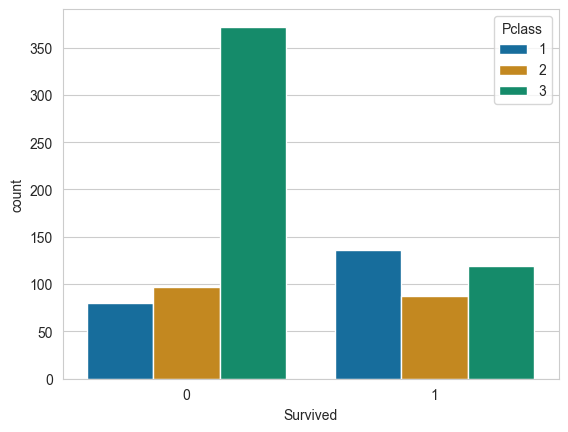

In [15]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train, palette='colorblind')

### Doin the same with the AGE column
- dropping na bcz it has a lot of missing values

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_28805/3914480385.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(),kde=False, bins=40, color='darkgreen')


<Axes: xlabel='Age'>

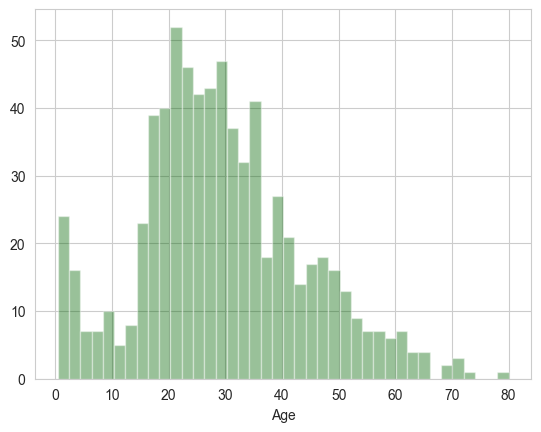

In [16]:
sns.distplot(train['Age'].dropna(),kde=False, bins=40, color='darkgreen')

### No. pf siblings the passenger had

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_28805/155987677.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data = train, palette='muted')


<Axes: xlabel='SibSp', ylabel='count'>

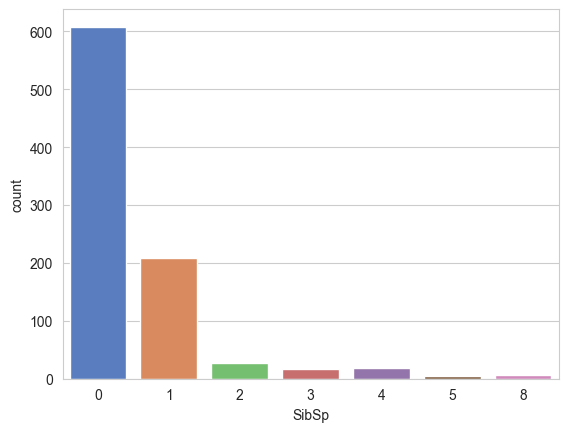

In [17]:
sns.countplot(x='SibSp', data = train, palette='muted')

- majority has no or 1 sibling and spouse

### Finding Train Fare Histogram , 

In [18]:
np.round(train['Fare'].mean(),2)

np.float64(32.2)

<Axes: >

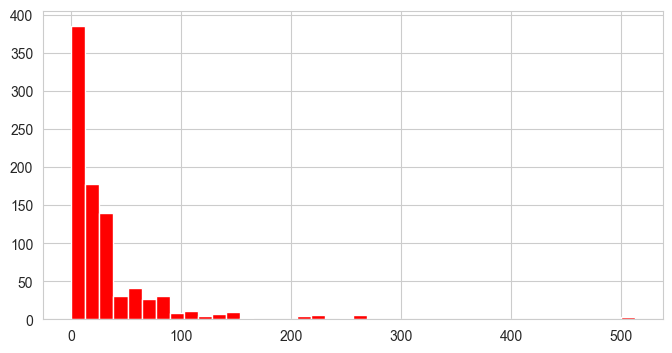

In [19]:
train['Fare'].hist(color='red',bins=40, figsize=(8,4))

## Data Cleaning ->
- Age and Cabin column to be handled (Filling with mean)
- Or any other techniques

##### Checking avg age by Passenger Class

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_28805/3581520545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age',data=train, palette='muted')


<Axes: xlabel='Pclass', ylabel='Age'>

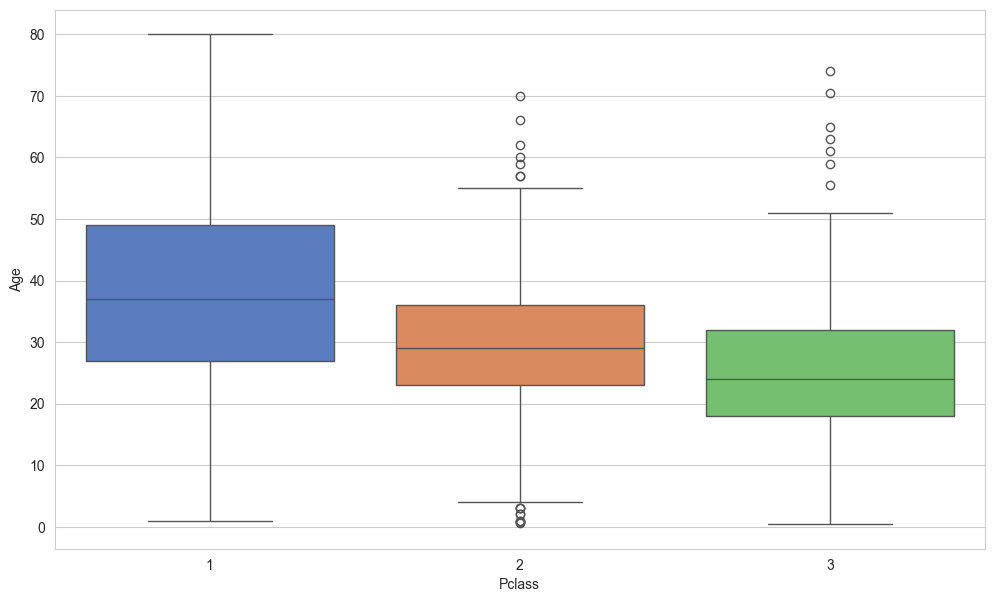

In [20]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y='Age',data=train, palette='muted')

### Findings->
- Passenger class 1 has Older Poeple 
- Than Other two classes Comparatively

- Pclass 1 has mean of 37
- Pclass 2 has mean of 29
- Pclass 3 has mean of 24

#### Fillin the nan values with the avg/mean but accrodin to the Pclass

In [21]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass ==1:
            return 37
        
        elif Pclass ==2:
            return 29
        
        elif Pclass == 3:
            return 24
    
    else:
        return Age


In [22]:
## Using this function to impute the values now->
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_28805/2794348225.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/var/folders/49/z4dsjwnj3bz30nknl9ffld4h0000gn/T/ipykernel_28805/2794348225.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


Checkin the imputation

<Axes: >

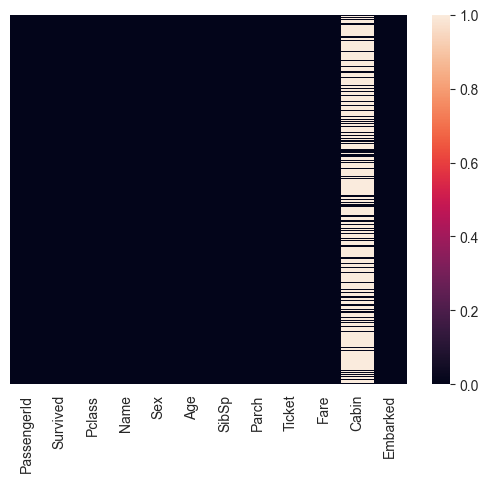

In [23]:
sns.heatmap(train.isnull(), yticklabels=False)

Age Column has been handled for the missin values

### Handling Cabin null Values -> 77% NaN

In [24]:
for feature in features_with_na:
    print(feature, np.round(train[feature].isnull().mean(),4))

Age 0.0
Cabin 0.771
Embarked 0.0022


The Cabin column requires Feature Enineerin to handle its NaN values, we are droppin it for now

In [25]:
train.drop('Cabin', axis=1, inplace=True)

In [26]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Droppin remaining NA values (too less to handle individually)

### Checking again->

In [27]:
print(train.isnull().sum().sum())

2


In [28]:
train.dropna(inplace=True)

In [29]:
print(train.isnull().sum().sum())

0


<Axes: >

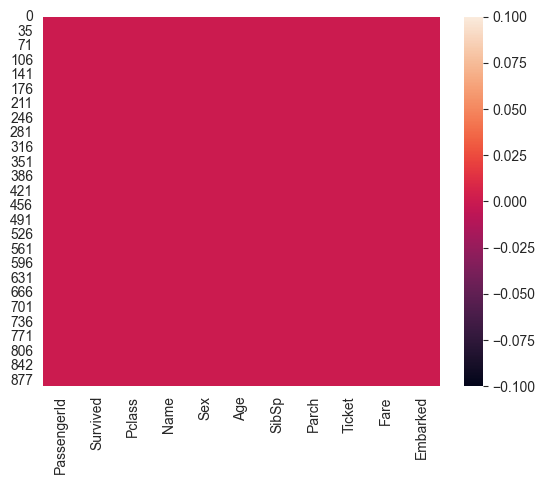

In [30]:
sns.heatmap(train.isnull())

#### Successfully hadnled all the NaN values

In [31]:
train.shape

(889, 11)

## Selecting Categorical features
- using get dummies function on column Sex and Embarked

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [33]:
embark = pd.get_dummies(train['Embarked'], drop_first=True).astype(int)

In [34]:
sex = pd.get_dummies(train['Sex'], drop_first=True).astype(int)

### Dropping all those columns that are not required

In [35]:
train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis=1, inplace=True)

In [36]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [37]:
train = pd.concat([train, sex ,embark], axis=1)

In [38]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


### Data is Ready for Model Building

### Train Test Split

In [39]:
train.drop('Survived',axis=1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,3,22.0,1,0,7.2500,1,0,1
1,2,1,38.0,1,0,71.2833,0,0,0
2,3,3,26.0,0,0,7.9250,0,0,1
3,4,1,35.0,1,0,53.1000,0,0,1
4,5,3,35.0,0,0,8.0500,1,0,1


In [40]:
train['Survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## Sci-Kit Learn enters the chat

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
x_train, x_test, y_train, y_test = train_test_split(train.drop("Survived",axis=1), 
train['Survived'],test_size=0.30,random_state=42)

In [43]:
x_train.isnull().sum().sum()


np.int64(0)

## Model Training

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
logmodel = LogisticRegression()
logmodel.fit(x_train, y_train)

/Users/mac/Desktop/Desktop_Files/Projects/Titanic Survival Prediction/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Prediction

In [46]:
prediction = logmodel.predict(x_test)

### Confusion matrix 

In [47]:
from sklearn.metrics import confusion_matrix

### Accuracy check

In [48]:
accuracy = confusion_matrix(y_test, prediction)

In [49]:
accuracy

array([[143,  24],
       [ 30,  70]])

In [50]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy = accuracy_score(y_test, prediction)

#### Model Accuracy

In [57]:
print( np.round(accuracy*100,2),'% Accuracy')

79.78 % Accuracy


## Model Evaluation
- Precision
- Recall
- F1-Score

In [60]:
from sklearn.metrics import classification_report

In [62]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       167
           1       0.74      0.70      0.72       100

    accuracy                           0.80       267
   macro avg       0.79      0.78      0.78       267
weighted avg       0.80      0.80      0.80       267



## Final Note: 

- This Logistic Regression Model had an accuracy of almost 80% 
- Althouh this is not too accurate like 90% but this was my first Loistic Regression Project, so worth the work!
- Ofcourse the accuracy can be imporved with mpre feature engineering, etc.

- Overall Accuracy: 80% of the predictions are correct.
- 
- Class 0 (Not Survived):
- 
- Precision 0.83 → When model predicts 0, it’s correct 83% of the time.
- 
- Recall 0.86 → Captures 86% of actual 0s.
- 
- F1-score 0.84 → Good balance between precision and recall.
- 
- Class 1 (Survived):
- 
- Precision 0.74 → Predictions for 1 are correct 74% of the time.
- 
- Recall 0.70 → Captures 70% of actual 1s.
- 
- F1-score 0.72 → Slightly lower performance than class 0.

#### The model performs well overall, with slightly better performance on predicting non-survivors (class 0). There’s room for improvement in identifying survivors (class 1).

## Thank you!